# Local LLM scoring pilot

An LLM can produce an intent name for a banking request, but that answer alone does not show how plausible the alternatives were. This notebook takes the first step from using an LLM as a text generator to using it as a scorer: assigning a value to each candidate intent so that we can later apply the project's calibration and routing methods.

We use **Qwen3-4B-Instruct-2507**, a model with about four billion parameters, trained to follow instructions. The [4-bit MLX version](https://huggingface.co/mlx-community/Qwen3-4B-Instruct-2507-4bit) stores its weights at reduced precision, making local inference practical on an M1 Mac with 16 GB of memory. MLX runs the model on the Mac's GPU; no external inference API is used. We pin the model revision and leave its weights unchanged throughout: this is inference, not fine-tuning.

What it shows:

- How a request becomes tokens and how Qwen generates an intent name from fixed instructions.
- How to score every candidate label, first token by token and then with one model call per candidate, checking that the two calculations agree.
- How summing or averaging token log-probabilities changes the relative weights assigned to labels of different lengths.
- Why a request can receive a confident-looking score even when it is ambiguous or its correct intent is absent from the candidate list.

The study uses only **three intents and five hand-written requests**. It establishes the scoring mechanism and its limitations, not Qwen's BANKING77 accuracy or a conformal coverage guarantee. The full dataset, independent calibration and automation-versus-error evaluation belong to the next stages.

Run the cells from top to bottom using the `llm-scorekit` kernel.

In [1]:
import sys
from time import perf_counter

import matplotlib.pyplot as plt
import mlx.core as mx
import mlx.nn as nn
import numpy as np
from mlx_lm import generate, load
from mlx_lm.sample_utils import make_sampler

print(sys.executable)
print(mx.default_device())

/Users/enzocanonero/miniforge3/envs/llm-scorekit/bin/python
Device(gpu, 0)


## 1. Load the model and its tokenizer

The model contains the learned weights. Its tokenizer converts text into token IDs and generated IDs back into text. A token can be a word, a word fragment or punctuation.

The first load downloads about 2.3 GB into the Hugging Face cache, outside this repository. Later runs reuse those files. The pinned revision keeps the model files fixed; inference runs on the Mac.

In [2]:
MODEL_ID = "mlx-community/Qwen3-4B-Instruct-2507-4bit"
MODEL_REVISION = "50d427756c6b1b2fe0c0a10f67fbda1fc8e82c1b"

load_start = perf_counter()
model, tokenizer = load(
    MODEL_ID,
    revision=MODEL_REVISION,
)
load_seconds = perf_counter() - load_start

print(f"Model loaded in {load_seconds:.1f} seconds")

Model loaded in 1.4 seconds


## 2. Generate one answer

The system message defines the task; the user message contains the customer request. The chat template adds the role markers expected by Qwen and starts the assistant's reply.

Generation repeatedly asks the model for next-token scores and uses a sampler to choose a token. We set the generation temperature to zero here, replacing the earlier sampling experiment: each choice is greedy, not random. The instruction to return one of our labels is still not a hard constraint.

In [3]:
candidate_intents = [
    "card_arrival",
    "lost_or_stolen_card",
    "pin_blocked",
]

intent_list = ", ".join(candidate_intents)
instructions = (
    "Classify the banking customer request. "
    f"Choose one intent: {intent_list}. "
    "Return only the intent name."
)


# Keep the instructions and candidate order fixed across requests.
def build_prompt(request: str) -> str:
    messages = [
        {"role": "system", "content": instructions},
        {"role": "user", "content": request},
    ]
    formatted_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    return formatted_prompt

In [4]:
customer_request = "Someone stole my wallet and my bank card was inside."
prompt = build_prompt(customer_request)
sampler = make_sampler(temp=0.0)

response = generate(
    model,
    tokenizer,
    prompt=prompt,
    sampler=sampler,
    max_tokens=24,
    verbose=False,
)

print(response)

lost_or_stolen_card


## 3. Inspect the candidate tokens

Each intent is a sequence of tokens, not a single model output class. With this tokenizer, the three labels have different lengths. That matters when we combine token probabilities into an intent score.

In [5]:
candidate_token_ids: list[list[int]] = []

for intent in candidate_intents:
    token_ids = tokenizer.encode(intent, add_special_tokens=False)
    candidate_token_ids.append(token_ids)
    token_pieces = tokenizer.convert_ids_to_tokens(token_ids)

    print(intent)
    print("Tokens:", token_pieces)
    print("Token IDs:", token_ids)
    print("Token count:", len(token_ids))
    print()

card_arrival
Tokens: ['card', '_arr', 'ival']
Token IDs: [4951, 11210, 3936]
Token count: 3

lost_or_stolen_card
Tokens: ['lost', '_or', '_st', 'olen', '_card']
Token IDs: [54337, 8734, 1261, 17205, 16888]
Token count: 5

pin_blocked
Tokens: ['pin', '_blocked']
Token IDs: [13273, 89223]
Token count: 2



## 4. Score a candidate instead of generating it

For each label, we ask for the probability of its first token, then its second token given the first, and so on. We supply the candidate tokens ourselves; no sampler is used. This is *teacher forcing*, but there is no training or weight update here.

Adding token log-probabilities gives the log-probability of the sequence. A higher score (closer to zero) means a more likely continuation, not a more reliably correct answer. We score only the label tokens, without an end-of-answer token, so this does not measure the probability of stopping exactly after the label.

In [6]:
prompt_token_ids = tokenizer.encode(prompt, add_special_tokens=False)
intent_log_scores: dict[str, float] = {}

for intent, intent_token_ids in zip(candidate_intents, candidate_token_ids):
    context_token_ids = prompt_token_ids.copy()
    total_log_probability = 0.0

    for token_id in intent_token_ids:
        model_input = mx.array([context_token_ids])
        logits = model(model_input)

        # The last position predicts the next token.
        next_token_logits = logits[0, -1, :]
        next_token_logits = next_token_logits.astype(mx.float32)
        next_token_log_probs = nn.log_softmax(next_token_logits, axis=-1)

        token_log_probability = next_token_log_probs[token_id].item()
        total_log_probability += token_log_probability

        # Continue with the candidate token, not a sampled token.
        context_token_ids.append(token_id)

    intent_log_scores[intent] = total_log_probability
    print(f"{intent}: {total_log_probability:.6f}")

card_arrival: -25.250798
lost_or_stolen_card: -0.000019
pin_blocked: -33.250010


## 5. Compute the same score in one pass per candidate

The loop above reprocesses the context for every token. Instead, we can supply the prompt followed by all but the last candidate token in one call. Qwen's causal attention prevents each position from seeing later tokens, so we still score each token using only the preceding context.

The last prompt position predicts the first label token: this explains the `-1` below. The function returns a NumPy array in candidate order. It is sufficient for this small pilot; sharing the prompt cache across 77 candidates is left for the full experiment.

In [7]:
# Score each fixed candidate with one model call.
def score_intents(request: str) -> np.ndarray:
    request_prompt = build_prompt(request)
    prompt_ids = tokenizer.encode(request_prompt, add_special_tokens=False)
    first_label_position = len(prompt_ids) - 1
    label_scores = []

    for label_ids in candidate_token_ids:
        input_ids = prompt_ids + label_ids[:-1]
        model_input = mx.array([input_ids])
        logits = model(model_input)

        # Align each prediction with the candidate token it scores.
        label_logits = logits[0, first_label_position:, :]
        label_logits = label_logits.astype(mx.float32)
        log_probabilities = nn.log_softmax(label_logits, axis=-1)
        positions = mx.arange(len(label_ids))
        target_ids = mx.array(label_ids)
        token_log_probabilities = log_probabilities[positions, target_ids]

        label_score = mx.sum(token_log_probabilities).item()
        label_scores.append(label_score)

    return np.asarray(label_scores, dtype=np.float64)


# Check the alignment against the step-by-step calculation.
reference_scores = np.array(list(intent_log_scores.values()))
one_pass_scores = score_intents(customer_request)
score_differences = np.abs(one_pass_scores - reference_scores)
print(f"Largest score difference: {score_differences.max():.6f}")

Largest score difference: 0.000002


## 6. Try clear, ambiguous and unsupported requests

These five requests are written by hand. The first three describe our available intents clearly. The fourth leaves delivery and loss unresolved; the fifth asks for something absent from our candidate list.

We still rank the same three labels every time. A highest-scoring label will therefore exist even when none is appropriate. We do not assign a ground-truth label to the last two requests or turn this demonstration into an accuracy estimate.

In [8]:
pilot_requests = {
    "Stolen card": customer_request,
    "Card delivery": "I ordered a card last week, but it has not arrived.",
    "Blocked PIN": "I entered the wrong PIN three times and now it is blocked.",
    "Ambiguous": "I cannot find my card. I am not sure whether it was delivered.",
    "Other request": "How can I change the address on my bank account?",
}

log_score_rows = []
scoring_start = perf_counter()

for case_name, request in pilot_requests.items():
    log_scores = score_intents(request)
    log_score_rows.append(log_scores)
    top_index = int(np.argmax(log_scores))
    top_intent = candidate_intents[top_index]

    print(f"{case_name}: {request}")
    print(f"Top intent: {top_intent}")
    print()

scoring_seconds = perf_counter() - scoring_start
log_score_matrix = np.stack(log_score_rows)
seconds_per_request = scoring_seconds / len(pilot_requests)
print(f"Scoring time per request: {seconds_per_request:.2f} seconds")

Stolen card: Someone stole my wallet and my bank card was inside.
Top intent: lost_or_stolen_card

Card delivery: I ordered a card last week, but it has not arrived.
Top intent: card_arrival

Blocked PIN: I entered the wrong PIN three times and now it is blocked.
Top intent: pin_blocked

Ambiguous: I cannot find my card. I am not sure whether it was delivered.
Top intent: lost_or_stolen_card

Other request: How can I change the address on my bank account?
Top intent: card_arrival

Scoring time per request: 0.74 seconds


## 7. Compare two ways to combine token scores

- **Sum:** the log-probability of the label sequence. Longer labels accumulate more non-positive terms, although their individual tokens may be very predictable.
- **Mean:** divide that sum by the label's token count. This is a length-normalized heuristic, not the log-probability of the whole label and not automatically a better classifier.

We apply softmax across the three candidate scores to make their relative weights easier to compare. Each row sums to one, but these are **not calibrated probabilities of correctness**. A large weight only means one candidate dominates this particular list. These transformations do not use the generation sampler.

In [9]:
# Normalize candidate scores separately for each request.
def relative_weights(log_scores: np.ndarray) -> np.ndarray:
    row_maxima = log_scores.max(axis=1, keepdims=True)
    shifted_scores = log_scores - row_maxima
    weights = np.exp(shifted_scores)
    row_totals = weights.sum(axis=1, keepdims=True)
    return weights / row_totals


token_counts = np.array([len(ids) for ids in candidate_token_ids])
mean_log_scores = log_score_matrix / token_counts
summed_weights = relative_weights(log_score_matrix)
mean_weights = relative_weights(mean_log_scores)

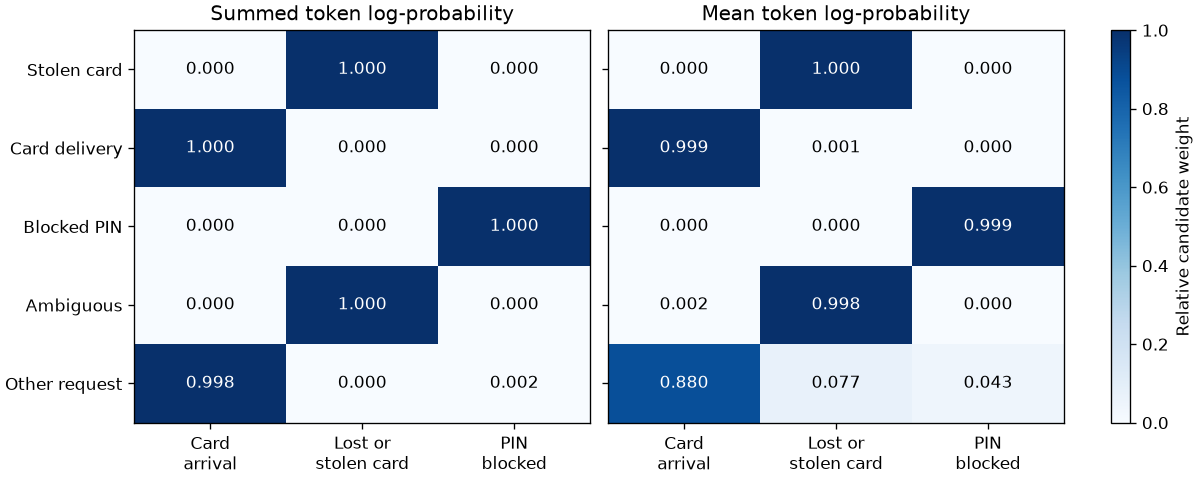

In [10]:
case_names = list(pilot_requests)
intent_labels = ["Card\narrival", "Lost or\nstolen card", "PIN\nblocked"]
comparisons = [
    (summed_weights, "Summed token log-probability"),
    (mean_weights, "Mean token log-probability"),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True, layout="constrained")

# Use the same colour scale for both scoring choices.
for axis, (weights, title) in zip(axes, comparisons):
    image = axis.imshow(weights, vmin=0, vmax=1, cmap="Blues", aspect="auto")
    axis.set_title(title)
    axis.set_xticks(range(len(candidate_intents)), intent_labels)
    axis.set_yticks(range(len(case_names)), case_names)

    for row in range(len(case_names)):
        for column in range(len(candidate_intents)):
            weight = weights[row, column]
            text_colour = "white" if weight > 0.6 else "black"
            axis.text(
                column,
                row,
                f"{weight:.3f}",
                ha="center",
                va="center",
                color=text_colour,
            )

fig.colorbar(image, ax=axes, label="Relative candidate weight")
plt.show()

## What this pilot tells us

- **The scoring calculation works as intended.** The one-pass and sequential scores agree to about two millionths in the original example. Both scoring choices select the expected intent for the three clear requests. This verifies the mechanism, not general classification accuracy.
- **Uncertainty in the request does not necessarily appear in the weights.** The ambiguous request strongly favours the lost-card label in both panels, even though the text leaves delivery unresolved.
- **A missing candidate can produce a confident-looking wrong answer.** For the address-change request, the summed scores give about 99.8% of the relative weight to card arrival. Averaging lowers this to about 88%, but still selects the same unsuitable label. Normalization cannot tell us that the right answer is absent.
- **Length normalization changes concentration, not the selected label in these examples.** The mean is worth comparing on development data, but this demonstration does not establish it as a better scoring rule. A high relative weight alone is not a reliable reason to automate.

The next milestone is a small development-only BANKING77 pilot with all 77 intents. Before evaluating it, we must fix label wording, the sum-versus-mean convention and end-of-answer treatment, and keep prompt development separate from final calibration and test data. Conformal coverage and automation-versus-error comparisons come after that.